Image loaded successfully

Original Image Information
--------------------------
Height : 619
Width  : 495
Channels: 3

After resizing:
Shape: (224, 224, 3)

After normalization:
Minimum pixel value: 0.0
Maximum pixel value: 1.0


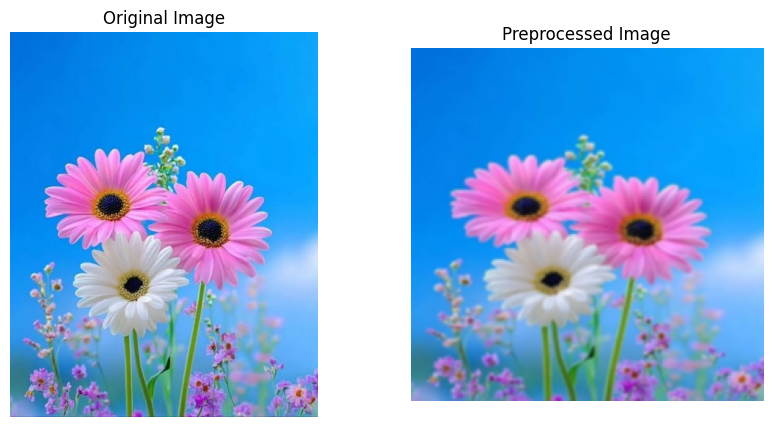

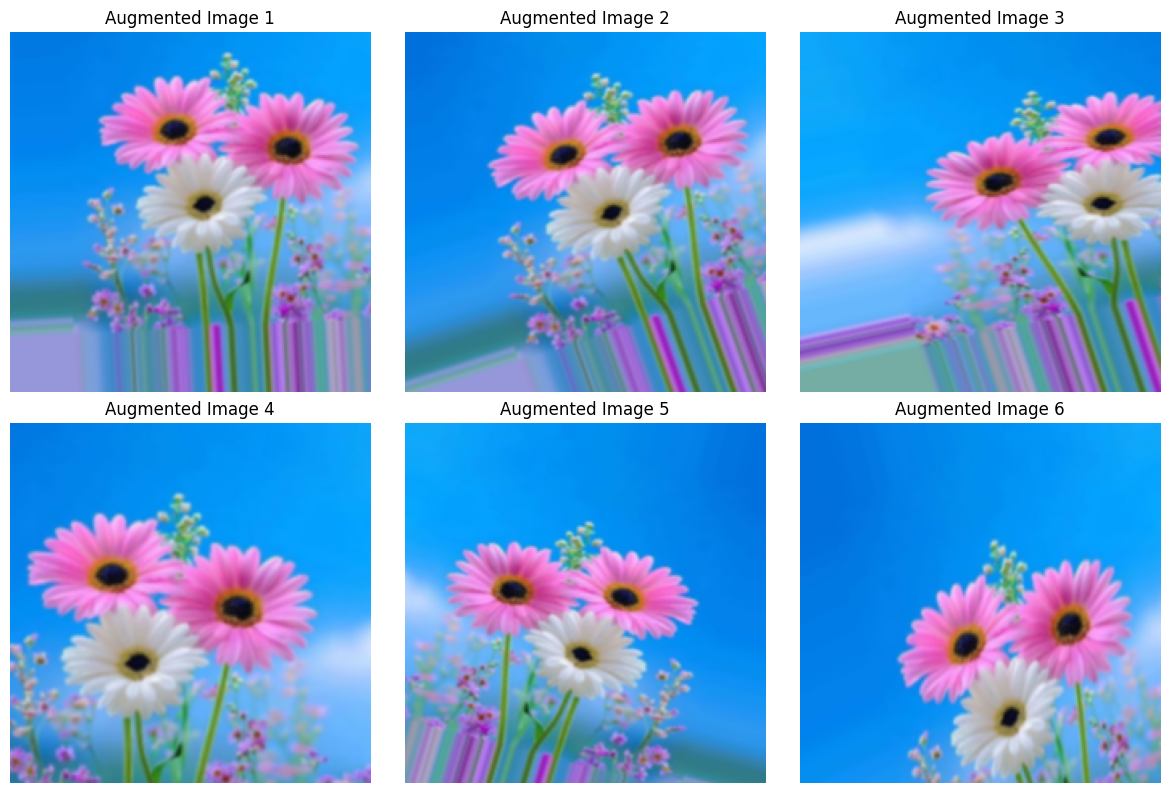


CNN Input Information
---------------------
Shape: (1, 224, 224, 3)
Data type: float32

Preprocessed image saved as:
preprocessed_flower.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================================================
# 1. IMAGE PATH
# ============================================================

image_path = "/content/flower image.jpg"


# ============================================================
# 2. LOAD IMAGE
# ============================================================

image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found!")
    exit()

print("Image loaded successfully")


# ============================================================
# 3. CHECK ORIGINAL IMAGE DETAILS
# ============================================================

print("\nOriginal Image Information")
print("--------------------------")
print("Height :", image.shape[0])
print("Width  :", image.shape[1])
print("Channels:", image.shape[2])


# ============================================================
# 4. CONVERT BGR TO RGB
# ============================================================

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# ============================================================
# 5. RESIZE IMAGE
# ============================================================

image_resized = cv2.resize(image_rgb, (224, 224))

print("\nAfter resizing:")
print("Shape:", image_resized.shape)


# ============================================================
# 6. NOISE REDUCTION
# ============================================================

image_denoised = cv2.GaussianBlur(
    image_resized,
    (3, 3),
    0
)


# ============================================================
# 7. NORMALIZATION
# ============================================================

image_normalized = image_denoised.astype(np.float32) / 255.0

print("\nAfter normalization:")
print("Minimum pixel value:", image_normalized.min())
print("Maximum pixel value:", image_normalized.max())


# ============================================================
# 8. DISPLAY ORIGINAL AND PREPROCESSED IMAGE
# ============================================================

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_normalized)
plt.title("Preprocessed Image")
plt.axis("off")

plt.show()


# ============================================================
# 9. DATA AUGMENTATION
# ============================================================

# Convert normalized image into batch format
image_batch = np.expand_dims(image_normalized, axis=0)

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode="nearest"
)


# ============================================================
# 10. GENERATE AUGMENTED IMAGES
# ============================================================

augmented_images = datagen.flow(
    image_batch,
    batch_size=1
)


# ============================================================
# 11. DISPLAY AUGMENTED IMAGES
# ============================================================

plt.figure(figsize=(12, 8))

for i in range(6):

    augmented_image = next(augmented_images)[0]

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image)
    plt.title("Augmented Image " + str(i + 1))
    plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 12. PREPARE IMAGE FOR CNN
# ============================================================

cnn_input = np.expand_dims(image_normalized, axis=0)

print("\nCNN Input Information")
print("---------------------")
print("Shape:", cnn_input.shape)
print("Data type:", cnn_input.dtype)


# ============================================================
# 13. SAVE PREPROCESSED IMAGE
# ============================================================

# Convert values back to 0-255
processed_image = (image_normalized * 255).astype(np.uint8)

# Convert RGB back to BGR before saving with OpenCV
processed_image_bgr = cv2.cvtColor(
    processed_image,
    cv2.COLOR_RGB2BGR
)

output_path = "preprocessed_flower.jpg"

cv2.imwrite(
    output_path,
    processed_image_bgr
)

print("\nPreprocessed image saved as:")
print(output_path)